# Exercise 5: Variational Auto Encoder
## Submission date: 08\06\2026, 23:59.

Submitted by:

 **Student 1 Name+ID

 **Student 2 Name+ID

<font color='red'>Before submission, please make sure that all the plots and results are present as a colab notebook file</font>


## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [1]:
## Standard libraries
import os
import math
import random
import numpy as np
import pandas as pd
from collections import defaultdict

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
# from IPython.display import set_matplotlib_formats
# %config InlineBackend.figure_formats = ['svg', 'pdf']
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

Using device cpu


<Figure size 640x480 with 0 Axes>

## Assignment 1

We first implement a helper `ContinuousRepresentation` class for accounting pixel values as continous.

In [2]:
class ContinuousRepresentation(object):
    def __call__(self, tensor):
        tensor = tensor * 255.0 
        noise = torch.rand_like(tensor) # Normal noise
        tensor = (tensor + noise) / 256.0
        return tensor

transform = transforms.Compose([
    transforms.ToTensor(),
    ContinuousRepresentation()
])

In [3]:
# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))

Train size: 50000
Validation size: 10000
Test size: 10000


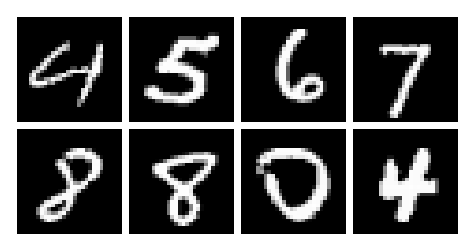

In [4]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=1)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

**Encoder** - $q_{\phi}(z|x)$, a network for approximating the parameters of the latent space $z$. <br>
**Decoder** - $p_{\theta}(x|z)$, a network for mapping vectors from the latent space $z$ into the parameters of the real data's distribution.

In [5]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.logs = defaultdict(list)

        # --------------- ENCODER ---------------- #
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # Output: (32, 14, 14)
            nn.ReLU(),
            nn.Conv2d(32, 128, kernel_size=3, stride=2, padding=1),  # Output: (128, 7, 7)
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=5, stride=2, padding=1), # Output: (256, 3, 3)
            nn.ReLU()
        )

        self.encoder_fc = nn.Sequential(
            nn.Linear(256 * 3 * 3, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_log_std = nn.Linear(256, latent_dim)

        # --------------- DECODER ---------------- #
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256 * 3 * 3),
            nn.ReLU()
        )

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=5, stride=2, padding=1, output_padding=0),  # Output: (128, 7, 7)
            nn.ReLU(),
            nn.ConvTranspose2d(128, 32, kernel_size=3, stride=2, padding=1, output_padding=1),   # Output: (16, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),    # Output: (1, 28, 28)
            nn.Sigmoid()
        )

    def log(self, key, value):
        self.logs[key].append(value)

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.encoder_fc(x)
        mu = self.fc_mu(x)
        log_std = self.fc_log_std(x)
        return mu, log_std
    
    def decode(self, z):
        z = self.decoder_fc(z)
        z = z.view(z.size(0), 256, 3 ,3) # Unflatten
        x_hat = self.decoder_conv(z)
        return x_hat

    def calc_elbo(self, x, var = 0.085 ** 2):
        # Encode to get posterior parameters
        mu, log_std = self.encode(x)

        # Reparameterization Trick
        std = torch.exp(log_std)
        q_z_x = torch.distributions.Normal(mu, std)
        z = q_z_x.rsample()

        # Decode to get reconstruction means
        x_hat = self.decode(z)

        # Reconstruction Log Likelihood simplified to scaled Mean Squared Error 
        mse = F.mse_loss(x_hat, x, reduction='sum') / x.size(0)
        rec_loss = mse / (2 * var)

        # KL Divergence
        p_z = torch.distributions.Normal(torch.zeros_like(mu), torch.ones_like(std))
        KLD = torch.distributions.kl_divergence(q_z_x, p_z).sum(dim=1).mean()

        # Negative ELBO (we minimize this loss)
        loss = rec_loss + KLD
        return loss, rec_loss, KLD
    
    @torch.no_grad()
    def sample(self, num_samples):
        # Sample from the standard isotropic Gaussian prior p(z)
        z = torch.randn(num_samples, self.latent_dim).to(device)
        # Pass through the decoder to get the means of p(x|z)
        samples = self.decode(z)
        return samples

    def training_step(self, batch):
        loss, rec_loss, KLD = self.calc_elbo(batch)
        self.log('train_elbo', loss.item())
        self.log('train_recon', rec_loss.item())
        self.log('train_KLD', KLD.item())
        return loss

    @torch.no_grad()
    def validation_step(self, loader):
        loss_obj = []
        for imgs, _ in loader:
          imgs = imgs.to(device)
          loss_obj.append(self.calc_elbo(imgs))
        
        loss_obj = torch.stack([torch.stack(x) for x in loss_obj])
        loss, rec_loss, KLD = loss_obj.mean(dim=0)

        # Log losses
        self.log('val_elbo', loss.item())
        self.log('val_recon', rec_loss.item())
        self.log('val_KLD', KLD.item())
        return loss

    @torch.no_grad()
    def test_step(self, loader):
        loss_obj = []
        for imgs, _ in loader:
          imgs = imgs.to(device)
          loss_obj.append(self.calc_elbo(imgs))

        loss_obj = torch.stack([torch.stack(x) for x in loss_obj])
        loss, rec_loss, KLD = loss_obj.mean(dim=0)
        # Log losses
        self.log('test_elbo', loss.item())
        self.log('test_recon', rec_loss.item())
        self.log('test_KLD', KLD.item())

        return loss

### Model Training

In [6]:
latent_dims = 20
model = VAE(latent_dim=latent_dims).to(device)
print("Num params: {:,}".format(sum(p.numel() for p in model.parameters())))

model = torch.compile(model.to(device))

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.99)
epochs = 20

Num params: 3,042,729


In [7]:
# Training loop
for epoch in range(epochs):
    model.train()
    losses = []
    print(f"Epoch {epoch+1}/{epochs}")

    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        loss = model.training_step(imgs)
        loss.backward()
        optimizer.step()

    scheduler.step()
    val_loss = model.validation_step(val_loader)

    losses.append(val_loss)

# Test loop
model.eval()
final_loss = model.test_step(test_loader)
print(f"Final ELBO: {final_loss}")

# Save the model
torch.save(model.state_dict(), 'vae_model.pth')

Epoch 1/20


/home/ordinary/projects/ordinaryLib/myenv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/20
Epoch 3/20
Epoch 4/20
Epoch 5/20
Epoch 6/20
Epoch 7/20
Epoch 8/20
Epoch 9/20
Epoch 10/20
Epoch 11/20
Epoch 12/20
Epoch 13/20
Epoch 14/20
Epoch 15/20
Epoch 16/20
Epoch 17/20
Epoch 18/20
Epoch 19/20
Epoch 20/20
Final ELBO: 597.7844848632812


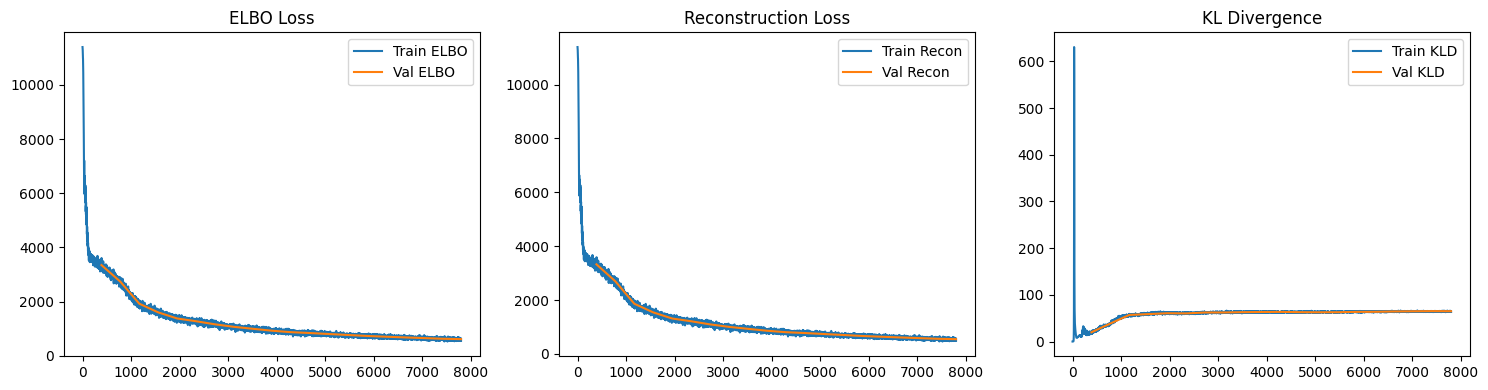

In [8]:
steps_per_epoch = len(model.logs['train_elbo']) // len(model.logs['val_elbo'])
val_x = [i * steps_per_epoch for i in range(1, len(model.logs['val_elbo']) + 1)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(model.logs['train_elbo'], label='Train ELBO')
axes[0].plot(val_x, model.logs['val_elbo'], label='Val ELBO')
axes[0].set_title('ELBO Loss')
axes[0].legend()

axes[1].plot(model.logs['train_recon'], label='Train Recon')
axes[1].plot(val_x, model.logs['val_recon'], label='Val Recon')
axes[1].set_title('Reconstruction Loss')
axes[1].legend()

axes[2].plot(model.logs['train_KLD'], label='Train KLD')
axes[2].plot(val_x, model.logs['val_KLD'], label='Val KLD')
axes[2].set_title('KL Divergence')
axes[2].legend()

plt.tight_layout()
plt.show()

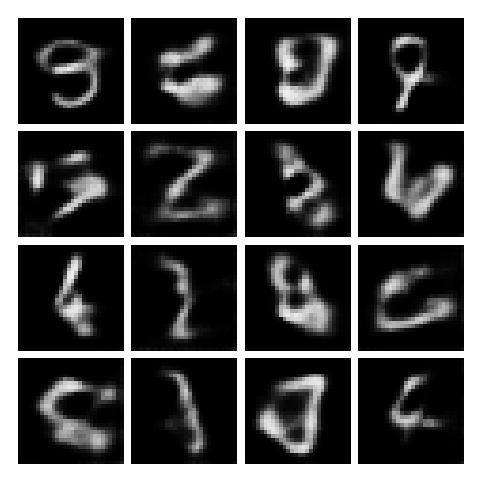

In [9]:
sampled_images = model.sample(num_samples=16)
show_imgs(sampled_images)

## Assignment 2

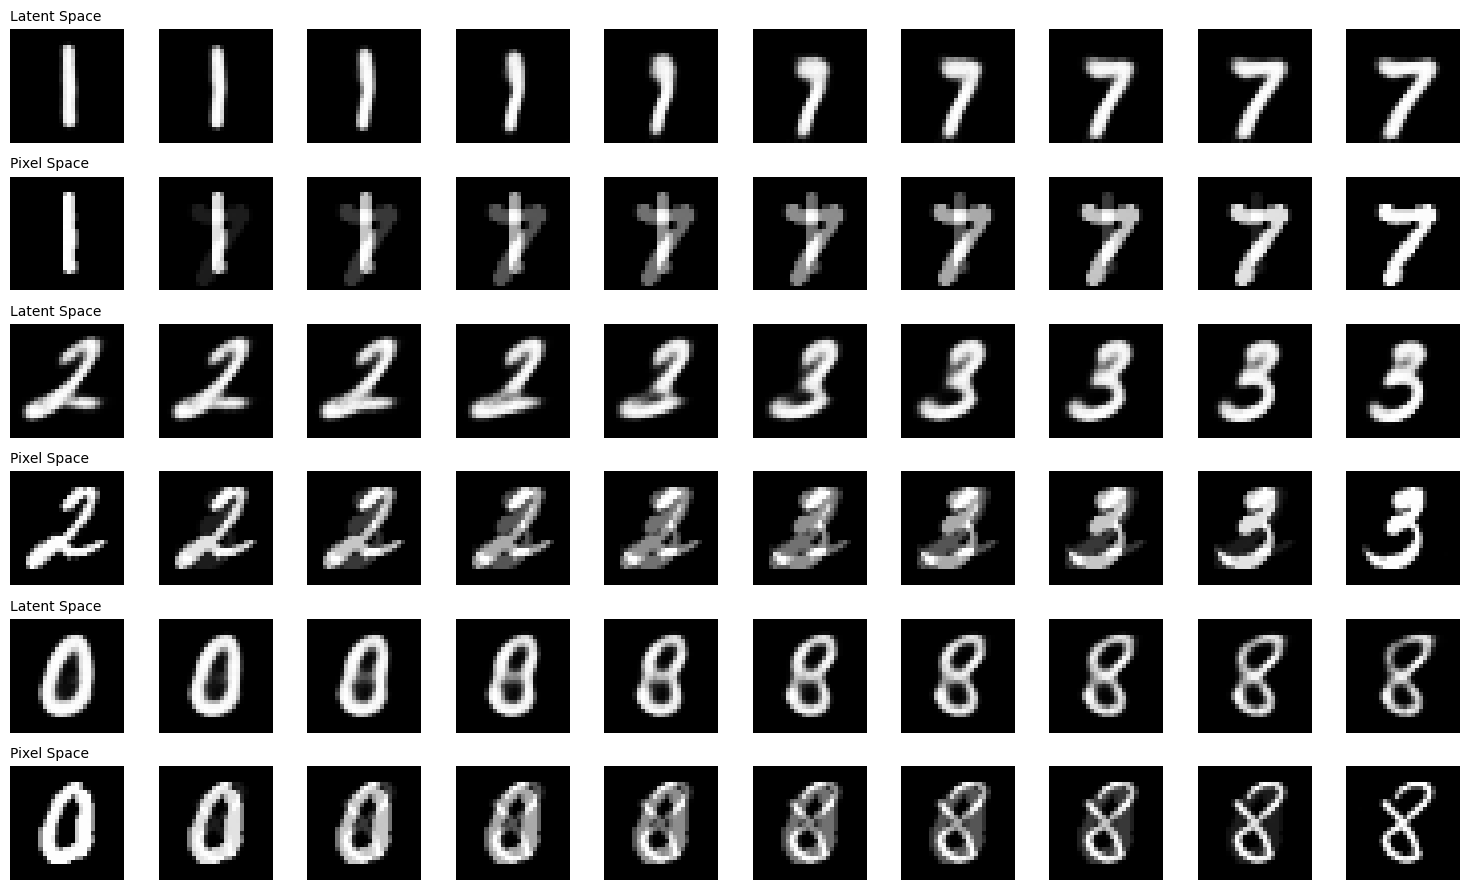

In [10]:
model.eval()

# Grab a few distinct digits from the validation set
images_by_label = defaultdict(list)
for imgs, labels in val_loader:
    for img, lbl in zip(imgs, labels):
        images_by_label[lbl.item()].append(img)
    if all(len(v) >= 2 for v in images_by_label.values()):
        break

# 3 distinct pairs to interpolate
pairs = [
    (images_by_label[1][0], images_by_label[7][0]), # 1 to 7
    (images_by_label[2][0], images_by_label[3][0]), # 2 to 3
    (images_by_label[0][0], images_by_label[8][0])  # 0 to 8
]

fig, axes = plt.subplots(6, 10, figsize=(15, 9))
steps = torch.linspace(0, 1, 10).to(device)

for idx, (img1, img2) in enumerate(pairs):
    x1 = img1.unsqueeze(0).to(device)
    x2 = img2.unsqueeze(0).to(device)
    
    # --- LATENT SPACE INTERPOLATION ---
    with torch.no_grad():
        # Get posterior means (representation)
        mu1, _ = model.encode(x1)
        mu2, _ = model.encode(x2)
        
        latent_rows = []
        for alpha in steps:
            z_interp = (1 - alpha) * mu1 + alpha * mu2
            x_hat_interp = model.decode(z_interp)
            latent_rows.append(x_hat_interp.squeeze().cpu().numpy())
            
    # --- PIXEL SPACE INTERPOLATION ---
    pixel_rows = []
    for alpha in steps:
        p_interp = (1 - alpha) * x1 + alpha * x2
        pixel_rows.append(p_interp.squeeze().cpu().numpy())
        
    # Plot Latent Space Row
    for col in range(10):
        ax = axes[idx * 2, col]
        ax.imshow(latent_rows[col], cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_title("Latent Space", loc='left', fontsize=10)
            
    # Plot Pixel Space Row
    for col in range(10):
        ax = axes[idx * 2 + 1, col]
        ax.imshow(pixel_rows[col], cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_title("Pixel Space", loc='left', fontsize=10)

plt.tight_layout()
plt.show()

## Assignment 3

In [11]:
model.eval()

# 1. Select 6 distinct images from the test loader
test_images = []
for imgs, _ in test_loader:
    for img in imgs:
        test_images.append(img)
        if len(test_images) == 6:
            break
    if len(test_images) == 6:
        break
test_images = torch.stack(test_images).to(device) # Shape: [6, 1, 28, 28]

# 2. Create the mask (m = 1 on top half, m = 0 on bottom half)
mask = torch.zeros_like(test_images)
mask[:, :, :14, :] = 1.0 # Top 14 rows are observed

# 3. Create the observed half (ground truth masked)
x_obs = test_images * mask

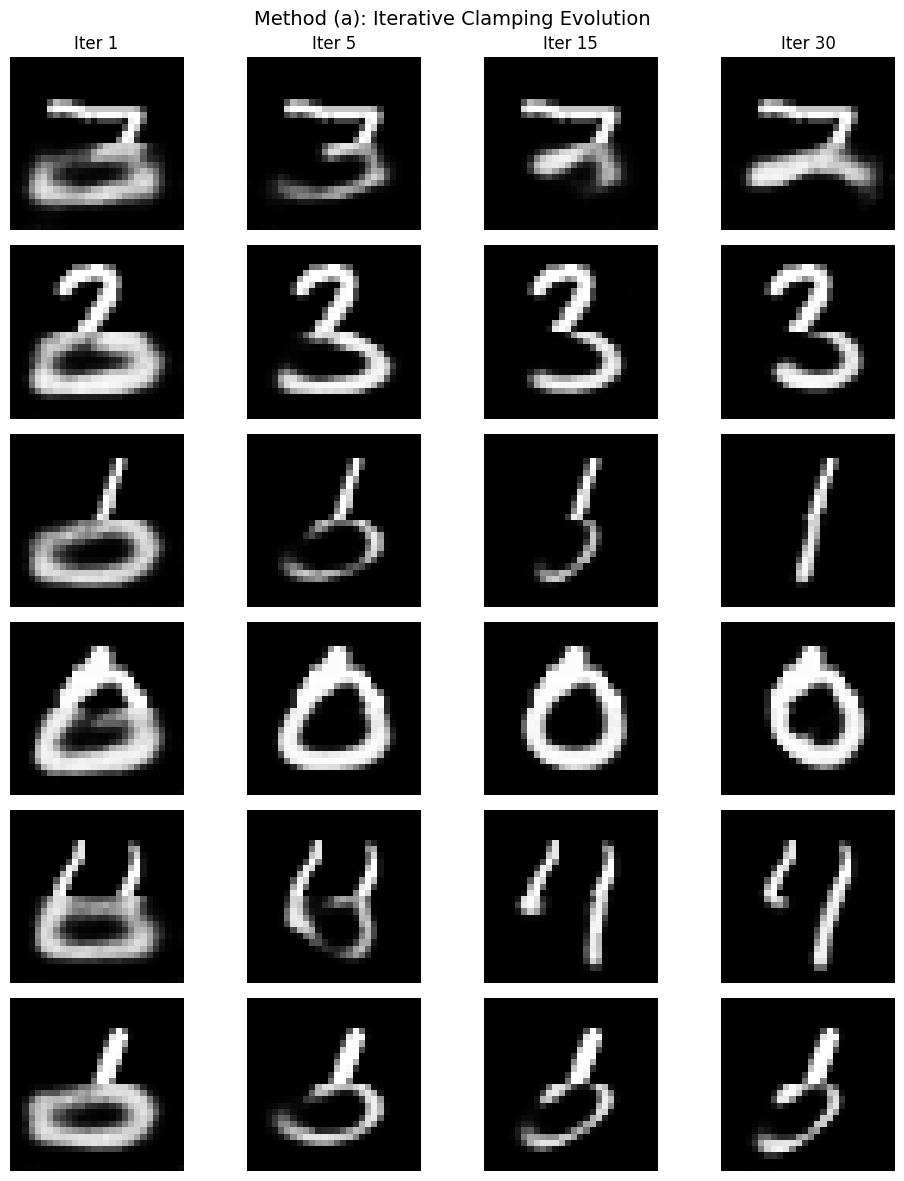

In [12]:
# Initialize missing pixels randomly in [0, 1]
x_t = x_obs.clone()
x_t[mask == 0] = torch.rand_like(x_t)[mask == 0]

snapshots = {}
iterations = 30

for i in range(iterations):
    with torch.no_grad():
        # Encode to latent space (using posterior mean)
        mu, _ = model.encode(x_t)
        # Decode back to pixel space
        x_hat = model.decode(mu)
        # Clamp observed pixels back to x_obs
        x_t = mask * x_obs + (1 - mask) * x_hat
        
    # Save snapshots at specific milestones
    if i + 1 in [1, 5, 15, 30]:
        snapshots[i + 1] = x_t.clone()

# Plotting snapshots evolution
fig, axes = plt.subplots(6, 4, figsize=(10, 12))
for row in range(6):
    for col, it in enumerate([1, 5, 15, 30]):
        ax = axes[row, col]
        ax.imshow(snapshots[it][row].squeeze().cpu().numpy(), cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(f"Iter {it}")
plt.suptitle("Method (a): Iterative Clamping Evolution", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Initialize z from the prior N(0, I)
z_param = nn.Parameter(torch.randn(6, latent_dims, device=device))
optimizer_b = optim.Adam([z_param], lr=0.1)

loss_curve_b = []

for step in range(150):
    optimizer_b.zero_grad()
    
    # Decode current z
    x_hat = model.decode(z_param)
    
    # Masked reconstruction loss + prior penalty
    var = 0.11 ** 2
    mse = F.mse_loss(x_hat * mask, x_obs, reduction='sum') / 6
    rec_loss = mse / (2 * var)
    prior_loss = 0.5 * torch.sum(z_param ** 2) / 6
    loss = rec_loss + prior_loss
    
    loss.backward()
    optimizer_b.step()
    loss_curve_b.append(loss.item())

with torch.no_grad():
    result_b = mask * x_obs + (1 - mask) * model.decode(z_param)

In [14]:
# Initialize free pixel parameters randomly
y_param = nn.Parameter(torch.randn(6, 1, 14, 28, device=device))
optimizer_c = optim.Adam([y_param], lr=0.1)

loss_curve_c = []

for step in range(150):
    optimizer_c.zero_grad()
    
    # Reconstruct full image by combining x_obs and sigmoid(y)
    x_free = torch.sigmoid(y_param)
    x_full = mask * x_obs + (1 - mask) * torch.cat([x_obs[:, :, :14, :], x_free], dim=2)
    
    # Compute Negative ELBO loss on the constructed image
    loss, _, _ = model.calc_elbo(x_full)
    
    loss.backward()
    optimizer_c.step()
    loss_curve_c.append(loss.item())

with torch.no_grad():
    result_c = mask * x_obs + (1 - mask) * torch.cat([x_obs[:, :, :14, :], torch.sigmoid(y_param)], dim=2)

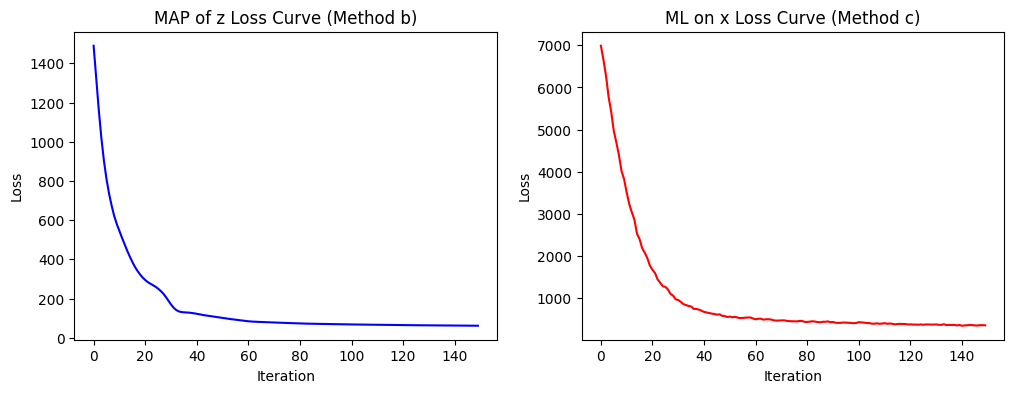

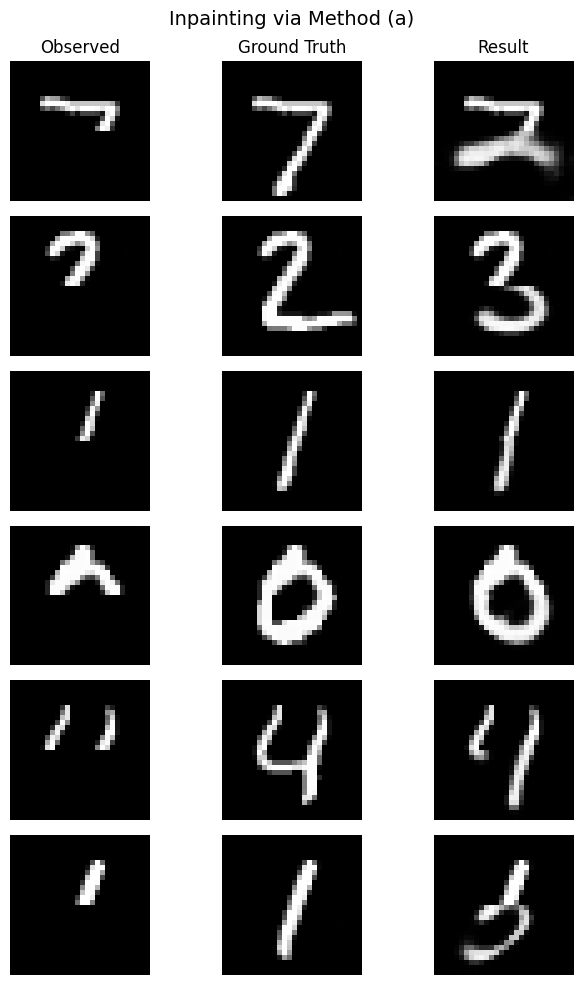

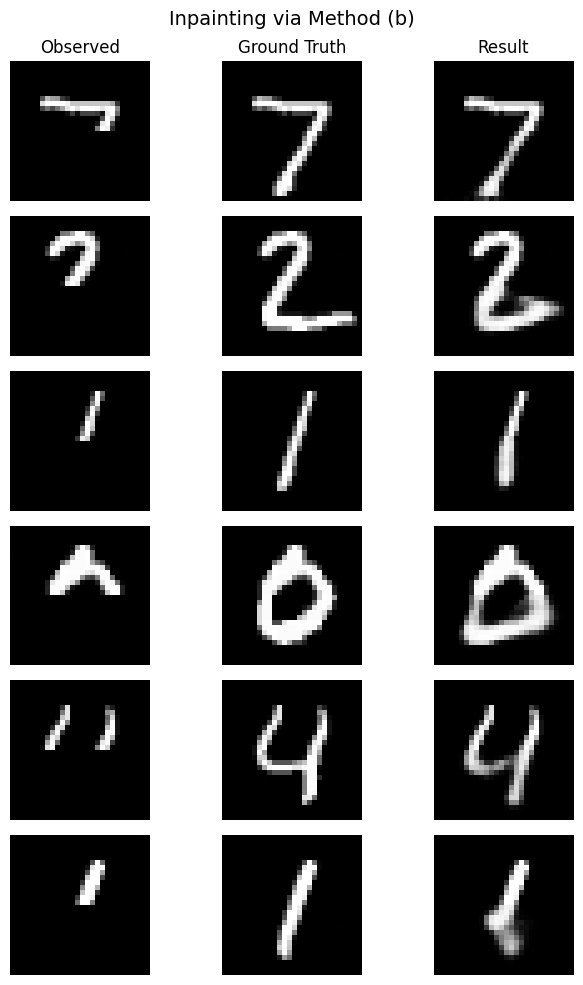

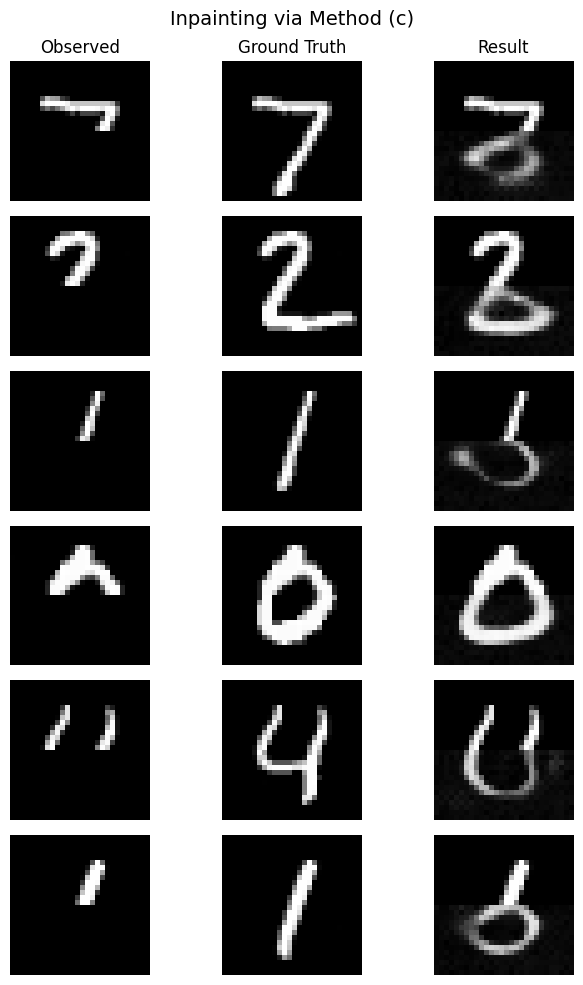

In [15]:
# Plot loss curves for b and c
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_curve_b, color='blue')
plt.title("MAP of z Loss Curve (Method b)")
plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(loss_curve_c, color='red')
plt.title("ML on x Loss Curve (Method c)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

# Final output visual comparison grid
methods = [("Method (a)", snapshots[30]), ("Method (b)", result_b), ("Method (c)", result_c)]

for name, res_tensor in methods:
    fig, axes = plt.subplots(6, 3, figsize=(7, 10))
    for row in range(6):
        # Column 1: Observed Half
        axes[row, 0].imshow(x_obs[row].squeeze().cpu().numpy(), cmap='gray')
        axes[row, 0].axis('off')
        if row == 0: axes[row, 0].set_title("Observed")
            
        # Column 2: Ground Truth
        axes[row, 1].imshow(test_images[row].squeeze().cpu().numpy(), cmap='gray')
        axes[row, 1].axis('off')
        if row == 0: axes[row, 1].set_title("Ground Truth")
            
        # Column 3: Result
        axes[row, 2].imshow(res_tensor[row].squeeze().cpu().numpy(), cmap='gray')
        axes[row, 2].axis('off')
        if row == 0: axes[row, 2].set_title("Result")
            
    plt.suptitle(f"Inpainting via {name}", fontsize=14)
    plt.tight_layout()
    plt.show()